# Research Question: 
Which model best classifies breast masses as malignant or benign, which features are most predictive, and can the feature set be reduced without sacrificing accuracy?

Data Link (https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)  

# Why we chose the dataset
We chose this dataset because it applies key machine learning methods to a real biomedical classification problem, aligning with our interest in the intersection of data science and healthcare.


In [32]:
#!pip install ucimlrepo # if this is the first time you run. Make sure to run this line to install.

import pandas as pd
from ucimlrepo import fetch_ucirepo

wdbc = fetch_ucirepo(id=17)
X = wdbc.data.features
y = wdbc.data.targets
features= ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
columns=[f'{stat}_{f}' for stat in ['mean', 'se', 'worst'] for f in features]
X.columns= columns
cancer_df = pd.concat([y, X], axis=1)
cancer_df = cancer_df.rename(columns={'Diagnosis': 'diagnosis'})
cancer_df['diagnosis_binary'] = cancer_df['diagnosis'].map({'M': 1, 'B': 0})
print(cancer_df.shape)
print(cancer_df.head())

(569, 32)
  diagnosis  mean_radius  mean_texture  mean_perimeter  mean_area  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   mean_symmetry  ...  worst_texture  worst_perimeter  worst_area  \
0         0.2419  ...          17.33       

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

In [34]:
X_model = cancer_df.drop(columns=['diagnosis', 'diagnosis_binary'])
y_model = cancer_df['diagnosis_binary']
#train/test split (temporary)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model, y_model, test_size=0.2, stratify=y_model, random_state=0
)


#split 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=0
)

print("Training set:", X_train.shape)
print("Validation set:", X_validation.shape)
print("Test set:", X_test.shape)


Training set: (455, 30)
Validation set: (57, 30)
Test set: (57, 30)


In [35]:
# train model on training
y_train_pred = best_tree.predict(X_train)
y_train_proba = best_tree.predict_proba(X_train)[:, 1]

print("Performance on TRAINING set")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1-score:", f1_score(y_train, y_train_pred))
print("AUC:", roc_auc_score(y_train, y_train_proba))
print(classification_report(y_train, y_train_pred, target_names=['Benign', 'Malignant']))


Performance on TRAINING set
Accuracy: 0.9516483516483516
Recall: 0.9647058823529412
F1-score: 0.9371428571428572
AUC: 0.969184726522188
              precision    recall  f1-score   support

      Benign       0.98      0.94      0.96       285
   Malignant       0.91      0.96      0.94       170

    accuracy                           0.95       455
   macro avg       0.94      0.95      0.95       455
weighted avg       0.95      0.95      0.95       455



Text(0.5, 1.0, "Decision Tree (max_depth=2, class_weight='balanced')")

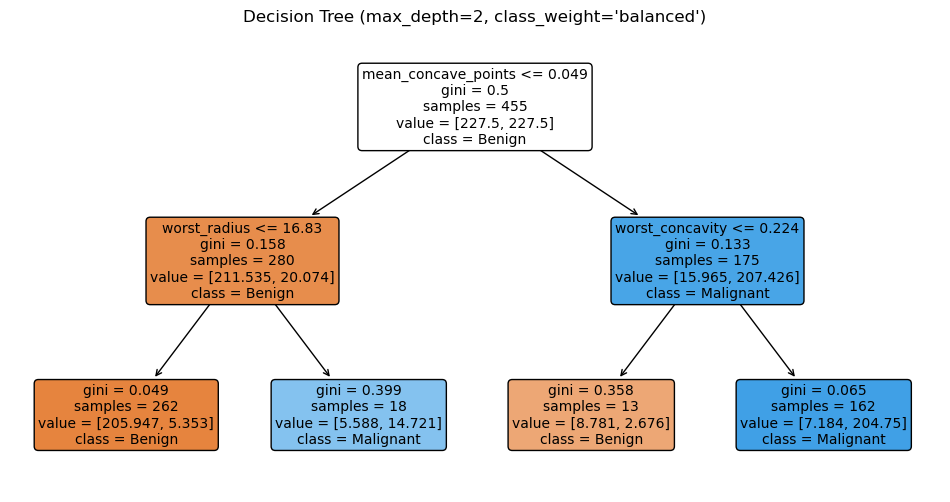

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plot_tree(best_tree, feature_names=X_train.columns, class_names=['Benign', 'Malignant'],
          filled=True, rounded=True, fontsize=10)
plt.title(f"Decision Tree (max_depth={best_depth}, class_weight='balanced')")

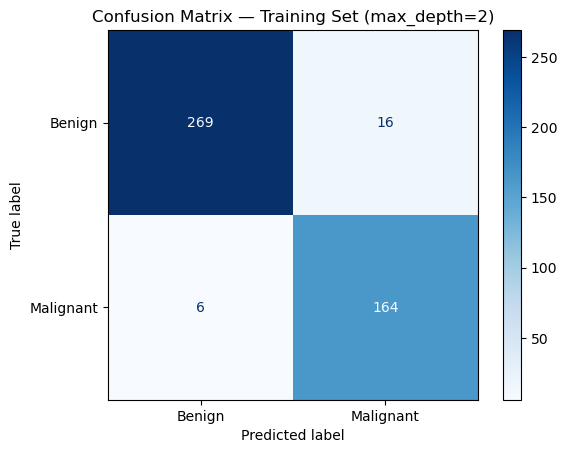

In [25]:
#confussion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix — Training Set (max_depth={best_depth})")
plt.show()

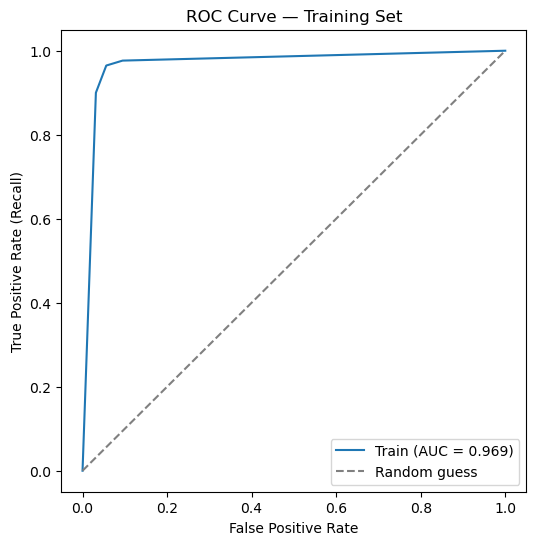

In [36]:
# ROC curve (training)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
auc_train = roc_auc_score(y_train, y_train_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {auc_train:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Training Set')
plt.legend()
plt.show()

In [37]:
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=0),
    X_train, y_train,
    scoring='recall')

print("CV recall scores:", cv_scores)
print ("mean CV recall:", cv_scores.mean())
print ("Srd CV recall:", cv_scores.std())

CV recall scores: [0.88235294 0.94117647 0.94117647 0.88235294 0.97058824]
mean CV recall: 0.9235294117647058
Srd CV recall: 0.03529411764705883
